# Classification d'images Fashion-MNIST avec TensorFlow


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow :", tf.__version__)
print("NumPy :", np.__version__)

TensorFlow : 2.20.0
NumPy : 2.1.3


In [2]:
#Étape 2 — Charger Fashion-MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train : (60000, 28, 28)
y_train : (60000,)
X_test  : (10000, 28, 28)
y_test  : (10000,)


In [3]:
#Étape 3 — Comprendre les 10 classes
classes = [
    "T-shirt / Top",
    "Pantalon",
    "Pull",
    "Robe",
    "Manteau",
    "Sandale",
    "Chemise",
    "Basket",
    "Sac",
    "Bottine"
]

print("Nombre de classes :", len(classes))
print(classes)

Nombre de classes : 10
['T-shirt / Top', 'Pantalon', 'Pull', 'Robe', 'Manteau', 'Sandale', 'Chemise', 'Basket', 'Sac', 'Bottine']


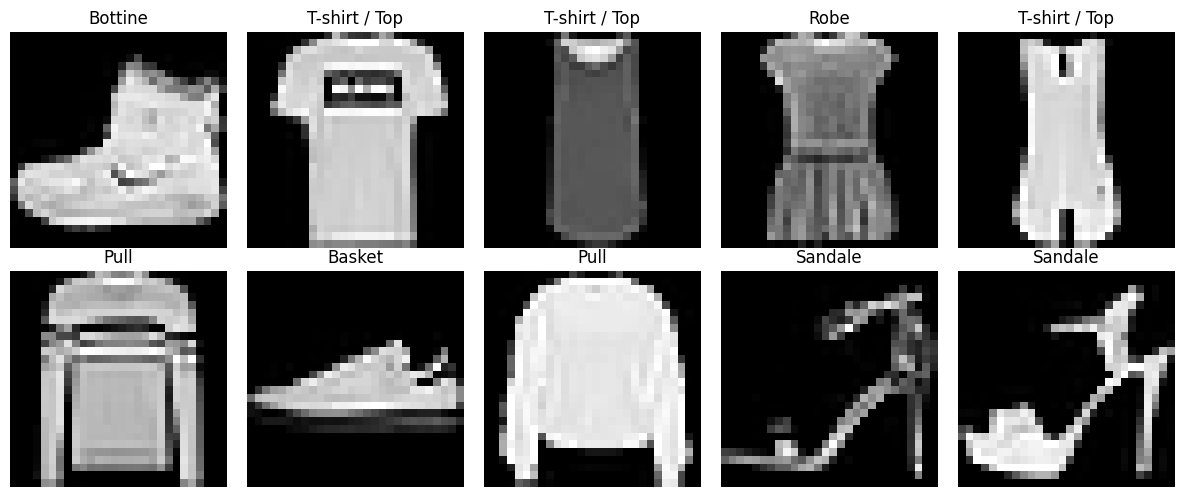

In [5]:
#Étape 4 — Visualiser quelques images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
#Étape 5 — Normaliser les images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0.0
Valeur maximale : 1.0


Étape 6 — Construire le réseau de neurones

In [7]:


model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Étape 7 — Compiler le modèle

In [8]:
# Compilation du modèle

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modèle compilé avec succès.")

Modèle compilé avec succès.


Étape 8 — Entraîner le réseau

In [9]:
# Entraînement du réseau de neurones

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8219 - loss: 0.5011 - val_accuracy: 0.8517 - val_loss: 0.4008
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8638 - loss: 0.3740 - val_accuracy: 0.8652 - val_loss: 0.3642
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8779 - loss: 0.3359 - val_accuracy: 0.8605 - val_loss: 0.3737
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8843 - loss: 0.3133 - val_accuracy: 0.8673 - val_loss: 0.3811
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8904 - loss: 0.2957 - val_accuracy: 0.8767 - val_loss: 0.3408
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8959 - loss: 0.2795 - val_accuracy: 0.8710 - val_loss: 0.3544
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8997 - loss: 0.2677 - val_accuracy: 0.8830 - val_loss: 0.3250
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9039 - loss: 0.2562

Étape 9 — Tracer les courbes d'apprentissage

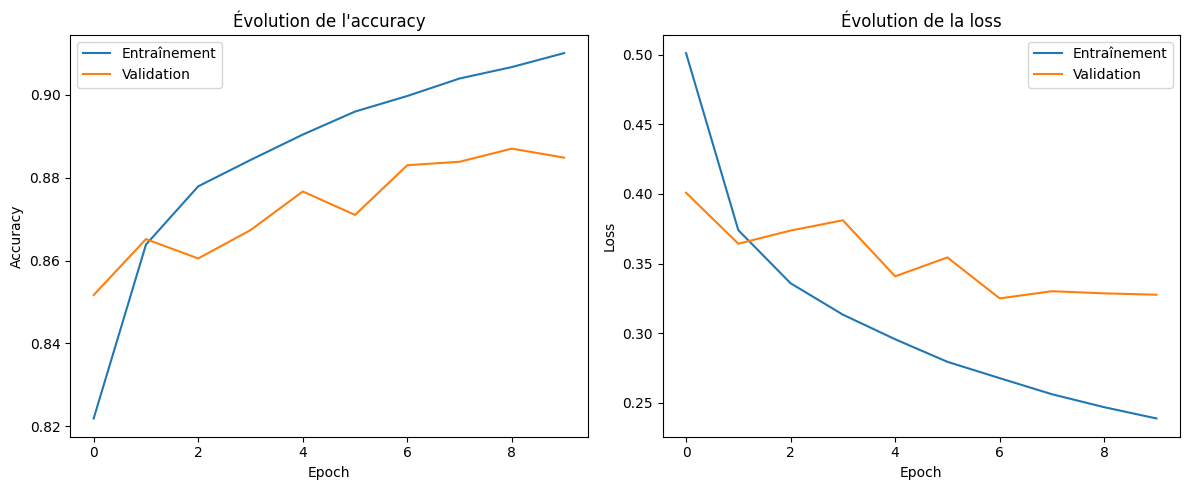

In [10]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Entraînement")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Évolution de l'accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Entraînement")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Évolution de la loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Étape 10 — Évaluer le modèle sur les données de test

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Loss sur le test :", round(test_loss, 4))
print("Accuracy sur le test :", round(test_accuracy * 100, 2), "%")

Loss sur le test : 0.3442
Accuracy sur le test : 88.23 %


Étape 11 — Faire les prédictions

In [12]:
# Prédictions sur les données de test

y_pred_proba = model.predict(X_test)

y_pred = np.argmax(y_pred_proba, axis=1)

print("Forme des prédictions :", y_pred.shape)
print("Premières prédictions :", y_pred[:10])
print("Vraies classes        :", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Forme des prédictions : (10000,)
Premières prédictions : [9 2 1 1 6 1 4 6 5 7]
Vraies classes        : [9 2 1 1 6 1 4 6 5 7]


Étape 12 — Matrice de confusion

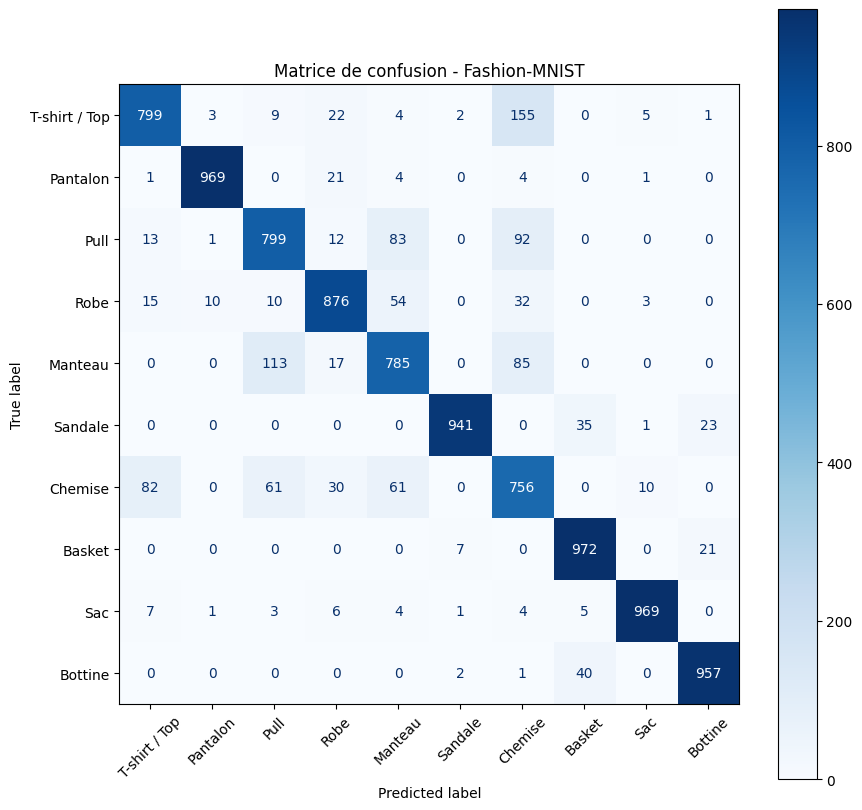

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Matrice de confusion - Fashion-MNIST")
plt.show()

Étape 13 — Rapport de classification

In [14]:
from sklearn.metrics import classification_report

# Rapport de classification
print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

               precision    recall  f1-score   support

T-shirt / Top       0.87      0.80      0.83      1000
     Pantalon       0.98      0.97      0.98      1000
         Pull       0.80      0.80      0.80      1000
         Robe       0.89      0.88      0.88      1000
      Manteau       0.79      0.79      0.79      1000
      Sandale       0.99      0.94      0.96      1000
      Chemise       0.67      0.76      0.71      1000
       Basket       0.92      0.97      0.95      1000
          Sac       0.98      0.97      0.97      1000
      Bottine       0.96      0.96      0.96      1000

     accuracy                           0.88     10000
    macro avg       0.89      0.88      0.88     10000
 weighted avg       0.89      0.88      0.88     10000



Étape 14 — Visualiser des prédictions

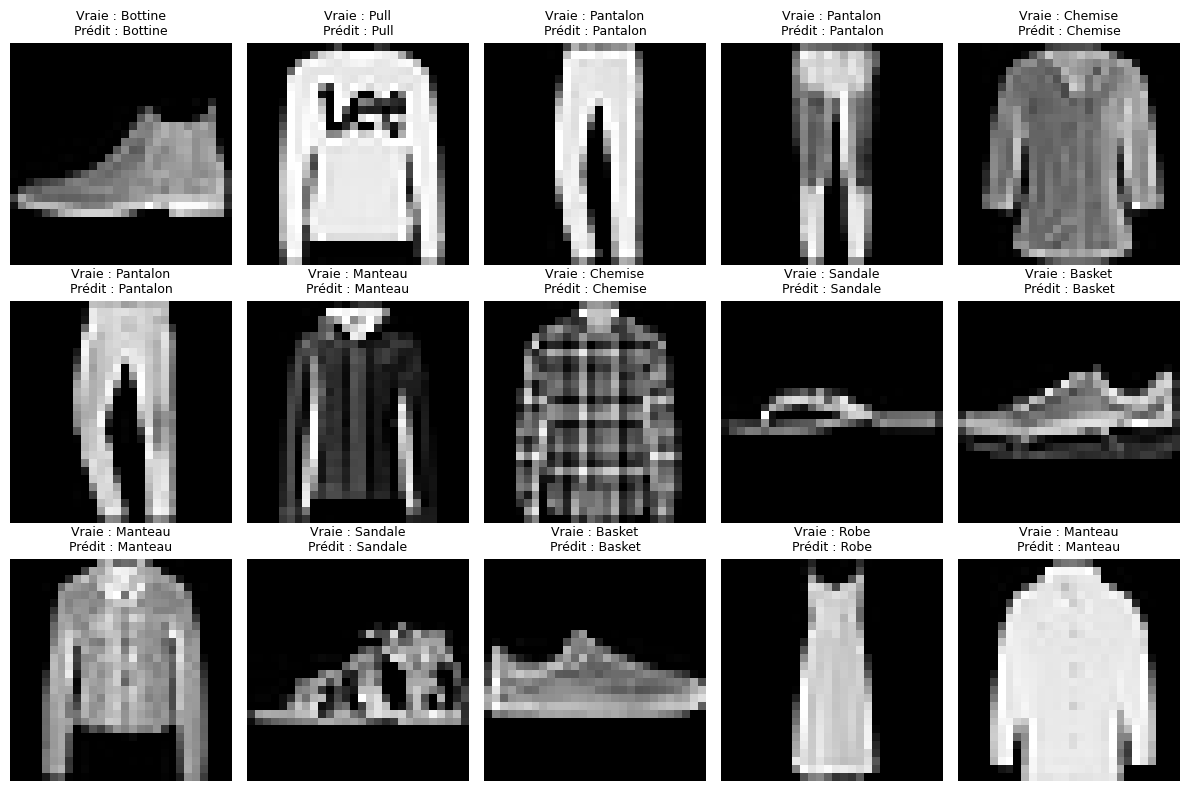

In [15]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test[i], cmap="gray")

    vraie_classe = classes[y_test[i]]
    classe_predite = classes[y_pred[i]]

    plt.title(
        f"Vraie : {vraie_classe}\nPrédit : {classe_predite}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Étape 15 — Afficher des images mal classées

Nombre d'erreurs : 1177


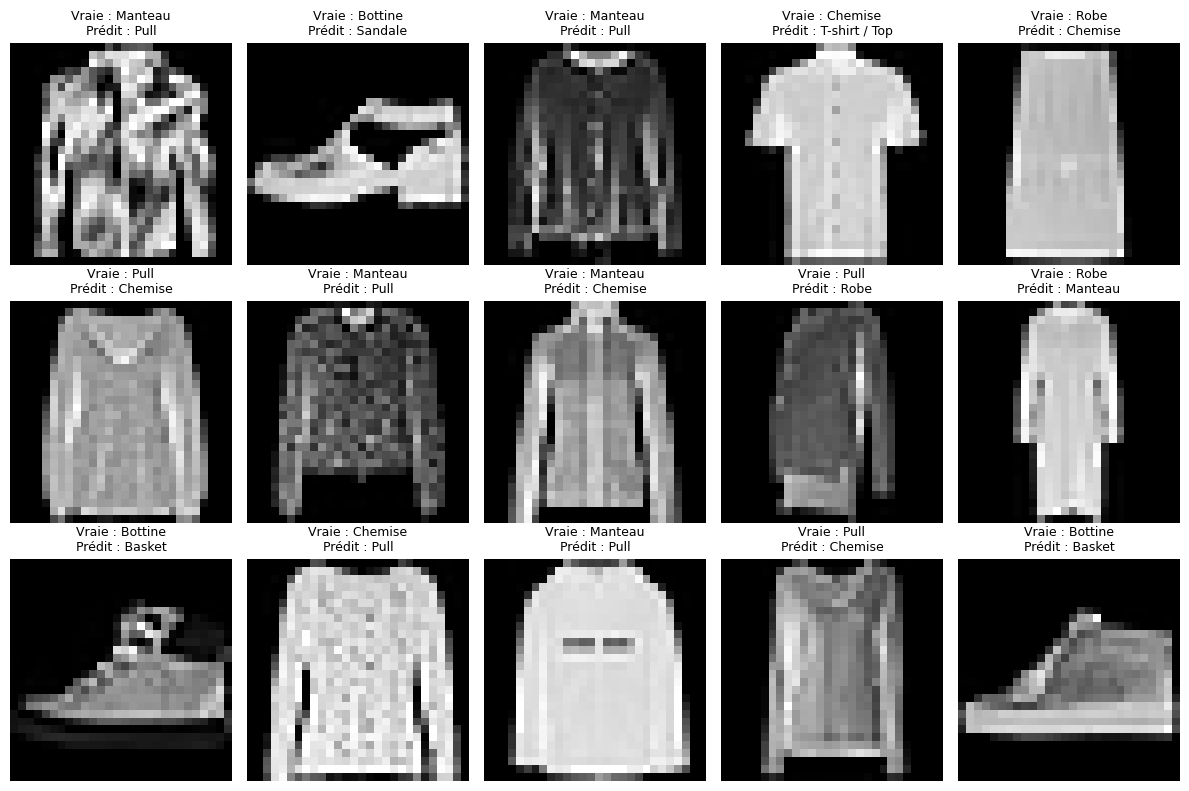

In [16]:
erreurs = np.where(y_pred != y_test)[0]

print("Nombre d'erreurs :", len(erreurs))

plt.figure(figsize=(12, 8))

for i in range(15):
    index = erreurs[i]

    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")

    vraie_classe = classes[y_test[index]]
    classe_predite = classes[y_pred[index]]

    plt.title(
        f"Vraie : {vraie_classe}\nPrédit : {classe_predite}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()